# DCT Toolkit - Getting Started

This notebook demonstrates the **dct-toolkit** package for DCT-based smoothing and statistical operations.

## Contents
1. [Installation & Setup](#setup)
2. [1D Signal Smoothing](#1d-smoothing)
3. [2D Cartesian Smoothing](#2d-cartesian)
4. [Polar Data Smoothing](#polar-smoothing)
5. [Robust Statistics with Gaps](#robust-stats)

In [1]:
# Install dct-toolkit if not already installed
# !pip install dct-toolkit

import numpy as np
import matplotlib.pyplot as plt

import dct_toolkit as dct

print(f"DCT Toolkit version: {dct.__version__}")

DCT Toolkit version: 0.4.1


## 1. 1D Signal Smoothing

Let's start with a simple 1D signal corrupted by noise. We'll apply DCT-based smoothing using a Gaussian kernel.

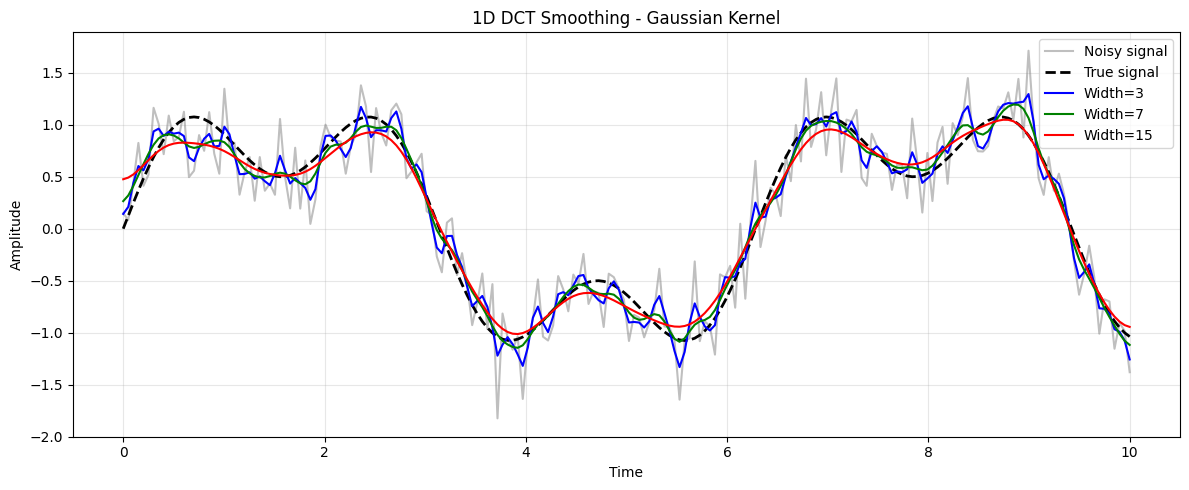

RMSE vs True Signal:
  Noisy:     0.2789
  Width=3:   0.1526
  Width=7:   0.1011
  Width=15:  0.1148


In [3]:
# Create a synthetic 1D signal
np.random.seed(42)

t = np.linspace(0, 10, 200)
true_signal = np.sin(t) + 0.5 * np.sin(3 * t)
noise = 0.3 * np.random.randn(len(t))
noisy_signal = true_signal + noise

# Apply DCT smoothing with different widths
smooth_3 = dct.dct_smooth(noisy_signal, width=3.0, kernel_type='gaussian')
smooth_7 = dct.dct_smooth(noisy_signal, width=7.0, kernel_type='gaussian')
smooth_15 = dct.dct_smooth(noisy_signal, width=15.0, kernel_type='gaussian')

# Plot results
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, noisy_signal, 'gray', alpha=0.5, label='Noisy signal')
ax.plot(t, true_signal, 'k--', linewidth=2, label='True signal')
ax.plot(t, smooth_3, 'b', label='Width=3')
ax.plot(t, smooth_7, 'g', label='Width=7')
ax.plot(t, smooth_15, 'r', label='Width=15')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('1D DCT Smoothing - Gaussian Kernel')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute RMSE for each width
print("RMSE vs True Signal:")
print(f"  Noisy:     {np.sqrt(np.mean((noisy_signal - true_signal)**2)):.4f}")
print(f"  Width=3:   {np.sqrt(np.mean((smooth_3 - true_signal)**2)):.4f}")
print(f"  Width=7:   {np.sqrt(np.mean((smooth_7 - true_signal)**2)):.4f}")
print(f"  Width=15:  {np.sqrt(np.mean((smooth_15 - true_signal)**2)):.4f}")

## 2. 2D Cartesian Smoothing

DCT smoothing extends naturally to 2D and higher dimensions. The smoothing is applied separably, making it computationally efficient.

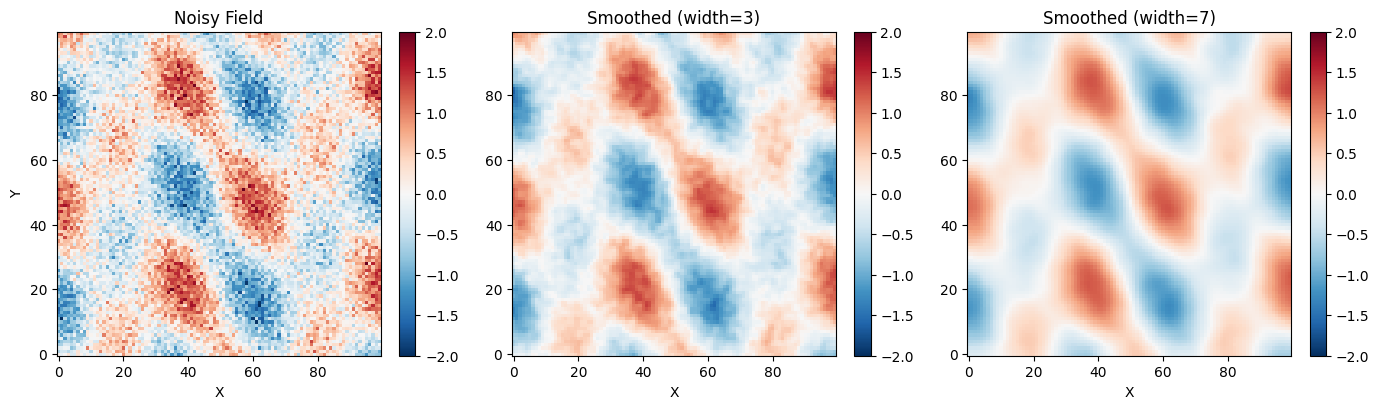


RMSE vs True Field:
  Noisy:       0.3010
  Width=3:     0.0972
  Width=7:     0.0550


In [4]:
# Create a synthetic 2D field with a sinusoidal pattern
np.random.seed(42)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# True field: combination of two sine waves
true_field = np.sin(X) * np.cos(Y) + 0.5 * np.sin(2*X + Y)

# Add noise
noise = 0.3 * np.random.randn(100, 100)
noisy_field = true_field + noise

# Apply 2D DCT smoothing
smooth_3 = dct.dct_smooth(noisy_field, width=3.0, coordinates='cartesian', kernel_type='gaussian')
smooth_7 = dct.dct_smooth(noisy_field, width=7.0, coordinates='cartesian', kernel_type='gaussian')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmin, vmax = -2, 2
im0 = axes[0].imshow(noisy_field, origin='lower', vmin=vmin, vmax=vmax, cmap='RdBu_r')
axes[0].set_title('Noisy Field')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(smooth_3, origin='lower', vmin=vmin, vmax=vmax, cmap='RdBu_r')
axes[1].set_title('Smoothed (width=3)')
axes[1].set_xlabel('X')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(smooth_7, origin='lower', vmin=vmin, vmax=vmax, cmap='RdBu_r')
axes[2].set_title('Smoothed (width=7)')
axes[2].set_xlabel('X')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"\nRMSE vs True Field:")
print(f"  Noisy:       {np.sqrt(np.mean((noisy_field - true_field)**2)):.4f}")
print(f"  Width=3:     {np.sqrt(np.mean((smooth_3 - true_field)**2)):.4f}")
print(f"  Width=7:     {np.sqrt(np.mean((smooth_7 - true_field)**2)):.4f}")

## 3. Real Radar Data Smoothing

This example uses real radar data from the COW1 deployment. We apply DCT-based smoothing to a PPI sweep and visualize the results using the same plotting style as the reference implementation.

### Setup
We use the exact same dataset path and `cflib` plotting helper as the original notebook, and replace only the smoothing call with `dct_toolkit`.

In [2]:
# Import additional libraries for radar data
import os
import sys

import cmweather  # registers ChaseSpectral colormap for matplotlib
import xarray as xr

# Add cflib to path (exact same plotting utility used in the reference notebook)
module_dir = os.path.expanduser('~/onedrive/code/research')
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

import cflib

In [3]:
ppi_file = '~/onedrive/code/research/smoothing/cfrad_QCed_20220223_023027.051_to_20220223_023410.833_COW1high_SUR.nc'
data = xr.open_dataset(ppi_file, decode_timedelta=False)
az_res_deg = 0.5
field = 'DBZHCC'

smoothing_width = 5  # pixels
data['DBZHCC_gaussian5'] = data[field]
data['DBZHCC_gaussian5'].values = dct.dct_smooth(
    data['DBZHCC_gaussian5'].values, 
    width=5, 
    coordinates='polar',
    az_res_deg=az_res_deg, 
    kernel_type='gaussian',
    az_boundary='reflective',
    max_iter=3
)
smoothing_width = 15  # pixels
data['DBZHCC_gaussian15'] = data[field]
data['DBZHCC_gaussian15'].values = dct.dct_smooth(
    data['DBZHCC_gaussian15'].values, 
    width=15, 
    coordinates='polar',
    az_res_deg=az_res_deg, 
    kernel_type='gaussian',
    az_boundary='periodic',
    max_iter=3
)

/Users/java1127/Library/CloudStorage/OneDrive-UCB-O365/Projects/DCT_interp_func/dct_toolkit/dct_toolkit/polar.py:231: UserWarning: Data shape (12076, 1180) has large first dimension. Ensure format is (n_azimuth, n_range).
  warnings.warn(


Using sweep index 12 with elevation 1.992773413658142°.
Using sweep index 12 with elevation 1.992773413658142°.
Using sweep index 12 with elevation 1.992773413658142°.


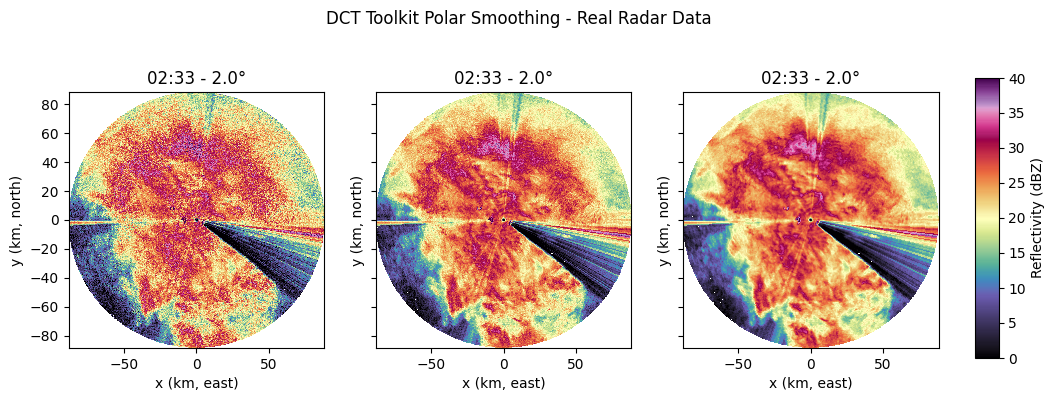

In [12]:
# Plot results using cflib (matching the reference notebook style)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

cflib.plot_cfradial(data, field, elv=2, cmap='ChaseSpectral', vmax=40, vmin=0, 
               ax=axes[0], rasterized=True)
cflib.plot_cfradial(data, 'DBZHCC_gaussian5', elv=2, cmap='ChaseSpectral', vmax=40, vmin=0,
               ax=axes[1], rasterized=True)
cflib.plot_cfradial(data, 'DBZHCC_gaussian15', elv=2, cmap='ChaseSpectral', vmax=40, vmin=0, ax=axes[2], rasterized=True)

# Add a common colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=0, vmax=40)
sm = plt.cm.ScalarMappable(cmap='ChaseSpectral', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Reflectivity (dBZ)')

plt.suptitle('DCT Toolkit Polar Smoothing - Real Radar Data', y=1.02)
plt.show()

### Comparison with Uncorrected Field

Let's also compare with the uncorrected reflectivity field to see the effect of smoothing on raw data.

/Users/java1127/Library/CloudStorage/OneDrive-UCB-O365/Projects/DCT_interp_func/dct_toolkit/dct_toolkit/polar.py:231: UserWarning: Data shape (12076, 1180) has large first dimension. Ensure format is (n_azimuth, n_range).
  warnings.warn(


Using sweep index 12 with elevation 1.992773413658142°.
Using sweep index 12 with elevation 1.992773413658142°.
Using sweep index 12 with elevation 1.992773413658142°.


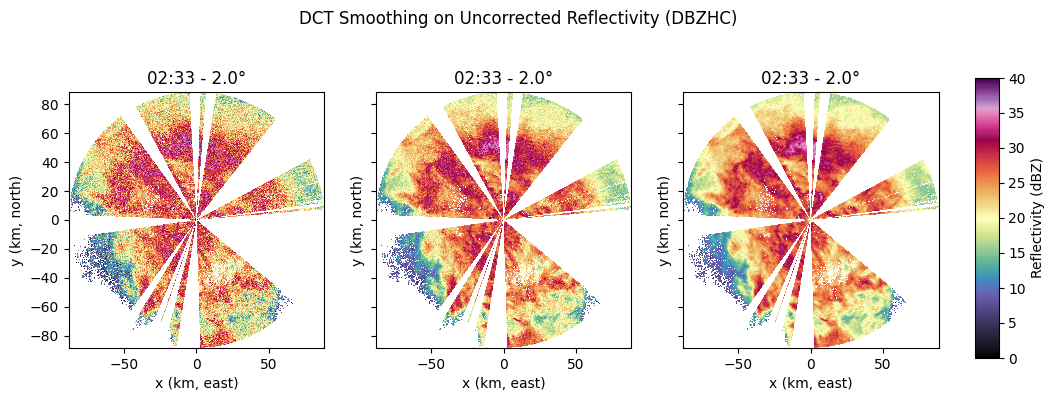

In [13]:
# Apply smoothing to uncorrected field
field = 'DBZHC'

smoothing_width = 5  # pixels
data['DBZHC_gaussian5'] = data[field].copy()
data['DBZHC_gaussian5'].values = dct.dct_smooth(
    data['DBZHC_gaussian5'].values, 
    width=smoothing_width, 
    coordinates='polar',
    az_res_deg=az_res_deg, 
    kernel_type='gaussian',
    az_boundary='periodic'
)

smoothing_width = 15  # pixels
data['DBZHC_gaussian15'] = data[field].copy()
data['DBZHC_gaussian15'].values = dct.dct_smooth(
    data['DBZHC_gaussian15'].values, 
    width=smoothing_width, 
    coordinates='polar',
    az_res_deg=az_res_deg, 
    kernel_type='gaussian',
    az_boundary='periodic'
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

cflib.plot_cfradial(data, 'DBZHC', elv=2, cmap='ChaseSpectral', vmax=40, vmin=0, 
               ax=axes[0], rasterized=True)
cflib.plot_cfradial(data, 'DBZHC_gaussian5', elv=2, cmap='ChaseSpectral', vmax=40, vmin=0,
               ax=axes[1], rasterized=True)
cflib.plot_cfradial(data, 'DBZHC_gaussian15', elv=2, cmap='ChaseSpectral', vmax=40, vmin=0, ax=axes[2], rasterized=True)

# Add a common colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=0, vmax=40)
sm = plt.cm.ScalarMappable(cmap='ChaseSpectral', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Reflectivity (dBZ)')

plt.suptitle('DCT Smoothing on Uncorrected Reflectivity (DBZHC)', y=1.02)
plt.show()

### Notes on the Implementation

The key difference between the original `dct_smoothing` module and `dct-toolkit`:

- **Original**: `dct_smoothing.apply_polar_dct_smoothing(data, az_res_deg=0.5, width_pixels=5, kernel_type='gaussian')`
- **dct-toolkit**: `dct.dct_smooth(data, width=5.0, coordinates='polar', az_res_deg=0.5, kernel_type='gaussian', az_boundary='periodic')`

The dct-toolkit API is more explicit about coordinate systems and uses `width` instead of `width_pixels` for consistency across 1D/2D/polar modes.

## 4. Robust Statistics with Gaps

One of the key features of the DCT toolkit is **Normalized Convolution** - the ability to compute statistics (mean, std) even when there are gaps (NaN/missing values) in the data.

This is done using the formula:
$$\mu = \frac{\text{smooth}(data \cdot mask)}{\text{smooth}(mask) + \epsilon}$$

where the mask is 1 for valid data and 0 for gaps.

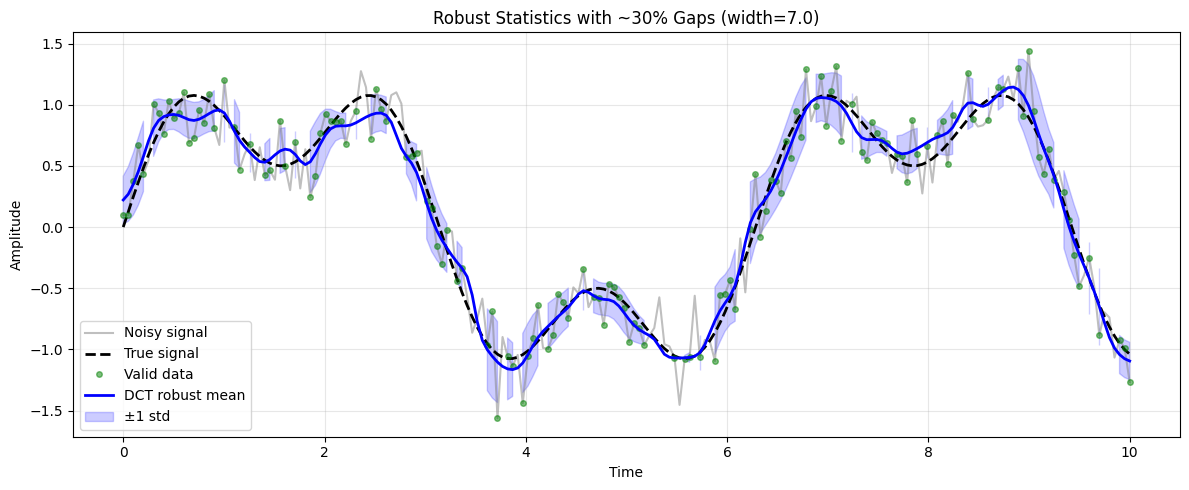

Gap fraction: 29.0%

RMSE vs True Signal:
  Noisy signal:     0.1859
  DCT robust mean:  0.0913


In [5]:
# Create 1D data with gaps
np.random.seed(42)

t = np.linspace(0, 10, 200)
true_signal = np.sin(t) + 0.5 * np.sin(3 * t)
noisy_signal = true_signal + 0.2 * np.random.randn(len(t))

# Create a mask with ~30% gaps
mask = np.random.rand(len(t)) > 0.3
data_with_gaps = noisy_signal.copy()
data_with_gaps[~mask] = np.nan

# Compute robust statistics
width = 7.0
robust_mean = dct.dct_mean(data_with_gaps, width=width, restore_input_nan=False)
robust_std = dct.dct_std(data_with_gaps, width=width)

# Compare with simple numpy mean (which ignores gaps)
numpy_mean = np.nanmean(noisy_signal)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, noisy_signal, 'gray', alpha=0.5, label='Noisy signal')
ax.plot(t, true_signal, 'k--', linewidth=2, label='True signal')
ax.plot(t[mask], noisy_signal[mask], 'o', markersize=4, color='green', alpha=0.5, label='Valid data')
ax.plot(t, robust_mean, 'b', linewidth=2, label='DCT robust mean')
ax.fill_between(t, robust_mean - robust_std, robust_mean + robust_std, 
                alpha=0.2, color='blue', label='±1 std')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'Robust Statistics with ~30% Gaps (width={width})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gap fraction: {np.sum(~mask) / len(mask):.1%}")
print(f"\nRMSE vs True Signal:")
print(f"  Noisy signal:     {np.sqrt(np.mean((noisy_signal - true_signal)**2)):.4f}")
print(f"  DCT robust mean:  {np.sqrt(np.mean((robust_mean - true_signal)**2)):.4f}")

## Summary

The **dct-toolkit** provides:

| Feature | Description |
|---------|-------------|
| **1D/2D DCT Smoothing** | Gaussian kernel smoothing with controlled width |
| **Polar Coordinates** | Adaptive kernel sizing for radar/lidar data |
| **Boundary Conditions** | Periodic or reflective for azimuth data |
| **Robust Statistics** | Mean and std even with missing/gap data |

### Next Steps

- Try different kernel types: `kernel_type='boxcar'` or `kernel_type='boxcar_discrete'`
- Experiment with different widths to find the right balance between smoothing and detail preservation
- For large gaps, consider using `dct_prefill()` to first fill gaps before computing statistics

### Installation

```bash
# Via pip
pip install dct-toolkit

# Via conda (once feed stock is merged)
conda install -c conda-forge dct-toolkit
```